# Clustering Socioeconómico de municipios en México

En esta libreta se realiza un análisis exploratorio de la incidencia delictiva a nivel municipal en México, utilizando variables socioconómicas para identificar patrones entre municipios. A través de técnicas de aprendizaje no supervisado, en particular K-Means, se busca agrupar municipios con características similares y analziar como estas agrupaciones se relacionan con la criminalidad. 

Los objetivos son: 
* Identificar los **tipos de municipios** según condiciones socioeconómicas
* Analizar cómo estos grupos se relacionan con la **incidencia delictiva**

## Setup

In [1]:
from pathlib import Path

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# scikit-learn imports
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

Defninimos las rutas al dataset que se utilizará: 

In [4]:
# data
base_dir = Path().resolve().parent

data_dir = base_dir / "data"

processed_dir = data_dir / "processed"

dataset_modeling_path = processed_dir / "dataset_model.csv"
assert dataset_modeling_path.exists() and dataset_modeling_path.is_file()

`dataset_model.csv` comprende un conjunto de datos de diferentes fuentes que combinan incidencia delictiva con variables de marginación y pobreza. Este dataset fue obtenido en la libreta [`notebooks/data_integration.ipynb`](./data_integration.ipynb).

Cargamos el dataset:

In [5]:
df = pd.read_csv(dataset_modeling_path)

La vista general del dataset:

In [6]:
df.head()

,anio,clave_entidad,clave_municipio,entidad,municipio,total_delitos,cvegeo,indice_marginacion,porcentaje_analfabetismo,porcentaje_sin_drenaje,porcentaje_sin_electricidad,porcentaje_hacinamiento,porcentaje_ingresos_bajos,poblacion_total,porcentaje_pobreza,porcentaje_pobreza_extrema,porcentaje_vulnerable_ingresos,porcentaje_carencia_servicios_basicos
0,2015,1,1001,Aguascalientes,Aguascalientes,18800,11001,60.318795,1.644738,0.104799,0.113169,10.339530,54.226594,948990.0,23.7,2.0,10.0,1.1
1,2015,1,1002,Aguascalientes,Asientos,247,11002,56.546071,3.526405,2.650373,0.486448,22.942305,78.565471,51536.0,40.1,4.1,6.6,7.4
2,2015,1,1003,Aguascalientes,Calvillo,554,11003,57.058251,4.491509,0.365177,0.516760,19.219858,79.259777,58250.0,45.8,4.5,3.8,3.1
3,2015,1,1004,Aguascalientes,Coso,160,11004,57.114030,3.144867,0.712855,0.577354,22.716866,81.726369,17000.0,37.0,3.4,9.9,4.4
4,2015,1,1005,Aguascalientes,Jess Mara,1285,11005,59.011762,2.380588,0.277034,0.354957,16.404575,56.748753,129929.0,26.3,3.3,7.7,2.3


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26153 entries, 0 to 26152
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   anio                                   26153 non-null  int64  
 1   clave_entidad                          26153 non-null  int64  
 2   clave_municipio                        26153 non-null  int64  
 3   entidad                                26153 non-null  object 
 4   municipio                              26153 non-null  object 
 5   total_delitos                          26153 non-null  int64  
 6   cvegeo                                 26153 non-null  int64  
 7   indice_marginacion                     26038 non-null  float64
 8   porcentaje_analfabetismo               26038 non-null  float64
 9   porcentaje_sin_drenaje                 26038 non-null  float64
 10  porcentaje_sin_electricidad            26038 non-null  float64
 11  po

In [8]:
df.isna().sum()

anio                                       0
clave_entidad                              0
clave_municipio                            0
entidad                                    0
municipio                                  0
total_delitos                              0
cvegeo                                     0
indice_marginacion                       115
porcentaje_analfabetismo                 115
porcentaje_sin_drenaje                   115
porcentaje_sin_electricidad              115
porcentaje_hacinamiento                  115
porcentaje_ingresos_bajos                115
poblacion_total                          115
porcentaje_pobreza                       136
porcentaje_pobreza_extrema               136
porcentaje_vulnerable_ingresos           136
porcentaje_carencia_servicios_basicos    136
dtype: int64

El procentaje de valores nulos por feature: 

In [9]:
df.isna().mean() * 100

anio                                     0.000000
clave_entidad                            0.000000
clave_municipio                          0.000000
entidad                                  0.000000
municipio                                0.000000
total_delitos                            0.000000
cvegeo                                   0.000000
indice_marginacion                       0.439720
porcentaje_analfabetismo                 0.439720
porcentaje_sin_drenaje                   0.439720
porcentaje_sin_electricidad              0.439720
porcentaje_hacinamiento                  0.439720
porcentaje_ingresos_bajos                0.439720
poblacion_total                          0.439720
porcentaje_pobreza                       0.520017
porcentaje_pobreza_extrema               0.520017
porcentaje_vulnerable_ingresos           0.520017
porcentaje_carencia_servicios_basicos    0.520017
dtype: float64

* Observamos que algunas features poseen valores nulos.

En `notebooks/data_integration.ipynb` se identificó que los registros nulos provienen del *joining* de los diferentes conjuntos. Podemos eliminarlos porque corresponden a municipios no censados y reprecentan una porción minúscula (\~0.5\%) del total de los datos. 

In [10]:
df.dropna(inplace=True)

In [11]:
df.shape

(26017, 18)

In [12]:
df.describe()

,anio,clave_entidad,clave_municipio,total_delitos,cvegeo,indice_marginacion,porcentaje_analfabetismo,porcentaje_sin_drenaje,porcentaje_sin_electricidad,porcentaje_hacinamiento,porcentaje_ingresos_bajos,poblacion_total,porcentaje_pobreza,porcentaje_pobreza_extrema,porcentaje_vulnerable_ingresos,porcentaje_carencia_servicios_basicos
count,26017.000000,26017.000000,26017.000000,26017.000000,2.601700e+04,26017.000000,26017.000000,26017.000000,26017.000000,26017.000000,26017.000000,2.601700e+04,26017.000000,26017.000000,26017.000000,26017.000000
mean,2020.189684,19.203213,19304.637737,831.904985,1.868759e+06,54.049790,9.977698,3.206978,1.481540,26.402922,81.817705,5.304298e+04,61.299704,16.728577,4.030007,39.116362
std,3.086985,7.500314,7515.210863,3408.042094,8.876382e+05,3.906281,7.520983,5.373943,2.795056,10.574489,11.848319,1.498222e+05,21.792670,15.047860,3.750234,29.651460
min,2015.000000,1.000000,1001.000000,0.000000,1.100100e+04,21.406635,0.353446,0.000000,0.000000,3.950392,28.453113,8.100000e+01,5.500000,0.000000,0.000000,0.100000
25%,2018.000000,14.000000,14057.000000,13.000000,1.414057e+06,51.968644,4.356157,0.651607,0.362061,18.584070,74.416319,4.940000e+03,44.800000,5.200000,1.100000,10.500000
50%,2020.000000,20.000000,20215.000000,58.000000,2.020215e+06,54.551371,8.045902,1.432707,0.813918,24.829351,84.314568,1.454200e+04,61.900000,12.100000,2.800000,33.500000
75%,2023.000000,24.000000,24052.000000,268.000000,2.424052e+06,56.757240,13.375008,3.360340,1.644255,32.547863,91.220837,3.718600e+04,79.300000,23.500000,5.800000,64.800000
max,2025.000000,32.000000,32058.000000,53995.000000,3.232058e+06,62.397145,53.071253,64.450424,53.065463,69.564018,100.000000,1.922523e+06,99.600000,84.400000,23.600000,100.000000


## Preprocesamiento

Dado que usaremos técnicas de clustering que son influenciadas por la magnitud en las features, es conveniente estandarizar sus valores. 

El clustering lo haremos considerando las features socioeconómicas: 

In [13]:
features_clustering = [
    'indice_marginacion',
    'porcentaje_analfabetismo',
    'porcentaje_sin_drenaje',
    'porcentaje_sin_electricidad',
    'porcentaje_hacinamiento',
    'porcentaje_ingresos_bajos',
    'porcentaje_pobreza',
    'porcentaje_pobreza_extrema'
]

X = df.loc[:, features_clustering]

Estandarizamos:

In [14]:
scaler = StandardScaler().set_output(transform='pandas')

X_scaled = scaler.fit_transform(X)

Verificamos resultados: 

In [15]:
X_scaled.describe()

,indice_marginacion,porcentaje_analfabetismo,porcentaje_sin_drenaje,porcentaje_sin_electricidad,porcentaje_hacinamiento,porcentaje_ingresos_bajos,porcentaje_pobreza,porcentaje_pobreza_extrema
count,2.601700e+04,2.601700e+04,2.601700e+04,2.601700e+04,2.601700e+04,2.601700e+04,2.601700e+04,2.601700e+04
mean,-6.379782e-16,-9.941098e-17,-3.277285e-18,-4.943238e-17,-9.831856e-17,-8.455396e-16,2.578131e-16,6.554570e-18
std,1.000019e+00,1.000019e+00,1.000019e+00,1.000019e+00,1.000019e+00,1.000019e+00,1.000019e+00,1.000019e+00
min,-8.356742e+00,-1.279678e+00,-5.967759e-01,-5.300676e-01,-2.123314e+00,-4.504066e+00,-2.560530e+00,-1.111713e+00
25%,-5.327795e-01,-7.474620e-01,-4.755205e-01,-4.005290e-01,-7.394212e-01,-6.246902e-01,-7.571363e-01,-7.661421e-01
50%,1.284062e-01,-2.568591e-01,-3.301682e-01,-2.388626e-01,-1.488110e-01,2.107397e-01,2.754630e-02,-3.075963e-01
75%,6.931148e-01,4.517195e-01,2.853861e-02,5.821647e-02,5.811212e-01,7.936410e-01,8.259952e-01,4.500010e-01
max,2.136947e+00,5.729887e+00,1.139659e+01,1.845577e+01,4.081703e+00,1.534618e+00,1.757519e+00,4.497166e+00


Con lo anterior, procedemos al clustering con K-Means. 

## K-Means

Primero, determinarémos el número de clusters óptimo. 

El método del codo (*elbow method*) permite identificar la cantidad óptima de clusters (`k`), ejecutando modelos con distintos valores y calculando, para cada uno, la suma de las distancias cuadradas dentro de los clusters (inercia). 

Al gráficar la inercia como función de `k`, se observa que la inercia disminuye a medida que aumenta el número de clusters. Cuando la inercia deja de cambiar significativamente, se observa un punto crítico llamado 'codo'. Este punto se puede interpretar como el valor óptimo de k. 

Consideremos ejecutar el método del codo con máximo 10 clusters:

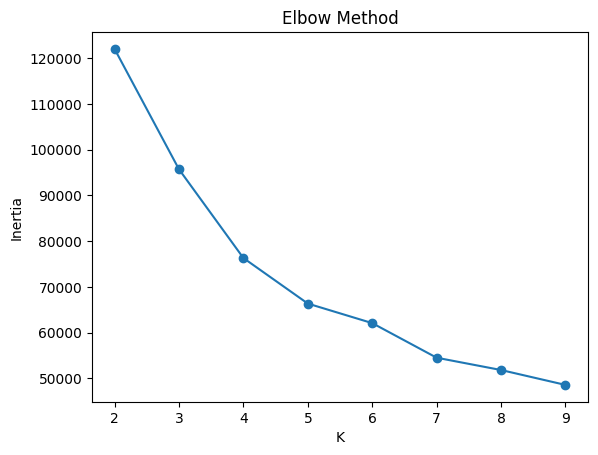

In [16]:
inertia = []
ks = list(range(2,10))

for k in ks:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)


plt.plot(ks, inertia, marker='o')
plt.xlabel('K')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

El elbow-plot muestra que a partir de 6 clusters, el cambio en la inercia se estabiliza en el rango 5000-6000 que comprende $k\geq 5$.

Consideremos el *Silhouette score* para comparar el resultado anterior. Esta métrica permite evaluar la calidad del agrupamiento midiendo la similaridad entre cada punto y su propio cluster. Es un número entre -1 y 1: valores cercanos a 1 indican clusters bien definidos y separados, valores cercanos a 0 sugieren solapamiento y valores negativos asignaciones incorrectas. Para elegir k, se calcula el promedio del Silhouete score. 

Evaluamos el silhouette score con `k=6`: 

In [ ]:
ks = list(range(2,10))
scores = []

for k in ks:
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    scores.append(score)

plt.plot(ks, scores, marker='o')
plt.xlabel('K')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Method')
plt.show()

El silhouette score presenta un máximo en `k=2`, una caída fuerte de 2 &rarr; 3, luego los valores se mantiene más bajos y relativamente planos. A partir de k=5 el clustering empeora bastante. 

Con lo anterior, se realizará el análisis de clusters con `k=3`.

In [17]:
kmeans = KMeans(n_clusters=3, random_state=42)

_ = kmeans.fit(X_scaled)

Asignamos la etiqueta de los clusters al dataframe principal: 

In [18]:
df['cluster'] = kmeans.labels_

Verificamos resultados: 

In [19]:
df.head()

,anio,clave_entidad,clave_municipio,entidad,municipio,total_delitos,cvegeo,indice_marginacion,porcentaje_analfabetismo,porcentaje_sin_drenaje,porcentaje_sin_electricidad,porcentaje_hacinamiento,porcentaje_ingresos_bajos,poblacion_total,porcentaje_pobreza,porcentaje_pobreza_extrema,porcentaje_vulnerable_ingresos,porcentaje_carencia_servicios_basicos,cluster
0,2015,1,1001,Aguascalientes,Aguascalientes,18800,11001,60.318795,1.644738,0.104799,0.113169,10.339530,54.226594,948990.0,23.7,2.0,10.0,1.1,0
1,2015,1,1002,Aguascalientes,Asientos,247,11002,56.546071,3.526405,2.650373,0.486448,22.942305,78.565471,51536.0,40.1,4.1,6.6,7.4,0
2,2015,1,1003,Aguascalientes,Calvillo,554,11003,57.058251,4.491509,0.365177,0.516760,19.219858,79.259777,58250.0,45.8,4.5,3.8,3.1,0
3,2015,1,1004,Aguascalientes,Coso,160,11004,57.114030,3.144867,0.712855,0.577354,22.716866,81.726369,17000.0,37.0,3.4,9.9,4.4,0
4,2015,1,1005,Aguascalientes,Jess Mara,1285,11005,59.011762,2.380588,0.277034,0.354957,16.404575,56.748753,129929.0,26.3,3.3,7.7,2.3,0


Consideremos visualizar los grupos en el espacio bidimensional usando PCA: 

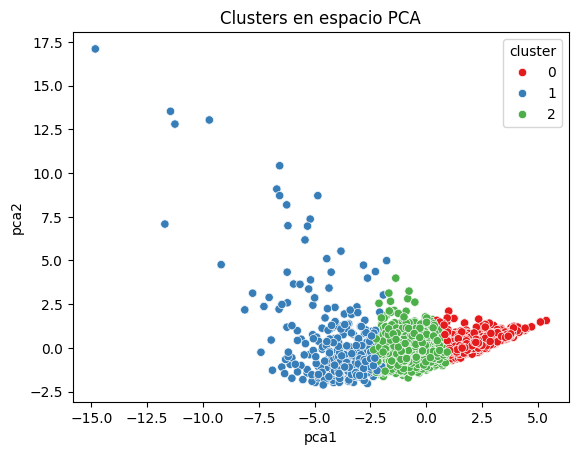

In [20]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

df['pca1'] = X_pca[:,0]
df['pca2'] = X_pca[:,1]

sns.scatterplot(data=df, x='pca1', y='pca2', hue='cluster', palette='Set1')
plt.title('Clusters en espacio PCA')
plt.show()

La visualización de las componentes principales sugiere que ...

Procedemos al análisis de los clusters considerando las variables socieconómicas y su relación con la incidencia delictiva. 

### Análisis de clusters

La cantidad de registros en cada cluster:

In [21]:
df['cluster'].value_counts(normalize=True)

cluster
2    0.440597
0    0.397932
1    0.161471
Name: proportion, dtype: float64

* Los clusters`'2'` y `'0'` agrupan \~40\% de los datos cada uno, mientras que el cluster `'1'` agrupa \~20\% de los registros. 

Consideremos el promedio de cada feature por cluster: 

In [22]:
cluster_profile = df.groupby('cluster')[features_clustering].mean()
cluster_profile

,indice_marginacion,porcentaje_analfabetismo,porcentaje_sin_drenaje,porcentaje_sin_electricidad,porcentaje_hacinamiento,porcentaje_ingresos_bajos,porcentaje_pobreza,porcentaje_pobreza_extrema
cluster,,,,,,,,
0,57.352301,4.355467,1.176175,0.611403,17.992226,70.937152,40.212286,4.967150
1,47.860202,22.500332,7.136907,4.082602,41.307055,92.989103,89.015234,43.074577
2,53.335455,10.466172,3.600878,1.314173,28.537063,87.550525,70.187874,17.695734


Los resultados en el cluster `'0'`:

In [23]:
cluster_profile.loc[0, :]

indice_marginacion             57.352301
porcentaje_analfabetismo        4.355467
porcentaje_sin_drenaje          1.176175
porcentaje_sin_electricidad     0.611403
porcentaje_hacinamiento        17.992226
porcentaje_ingresos_bajos      70.937152
porcentaje_pobreza             40.212286
porcentaje_pobreza_extrema      4.967150
Name: 0, dtype: float64

Observamos: 

* Analfabetismo: bajo (4\%)
* Servicios: relativamente buenos
* Pobreza:
    * total: 40\%
    * extrema 5\%

Este cluster se caracteriza por condiciones relativamente buenos y niveles de marginación y pobreza moderados.

En el cluster `'1'`: 

In [24]:
cluster_profile.loc[1, :]

indice_marginacion             47.860202
porcentaje_analfabetismo       22.500332
porcentaje_sin_drenaje          7.136907
porcentaje_sin_electricidad     4.082602
porcentaje_hacinamiento        41.307055
porcentaje_ingresos_bajos      92.989103
porcentaje_pobreza             89.015234
porcentaje_pobreza_extrema     43.074577
Name: 1, dtype: float64

* Alto analfabetismo: muy alto &rarr; 22\%
* Servicios básicos deficientes
    * Sin drenaje: alto &rarr; 7\%
    * Sin electricidad: alto &rarr; 5\%
* Predomina la pobreza:
    * total: 89\%
    * extrema: 43\%

Este cluster se caracteriza por una alta merginación, deficiencia estructural considerable y alta pobreza. 

El cluster `'2'`: 

In [25]:
cluster_profile.iloc[2, :]

indice_marginacion             53.335455
porcentaje_analfabetismo       10.466172
porcentaje_sin_drenaje          3.600878
porcentaje_sin_electricidad     1.314173
porcentaje_hacinamiento        28.537063
porcentaje_ingresos_bajos      87.550525
porcentaje_pobreza             70.187874
porcentaje_pobreza_extrema     17.695734
Name: 2, dtype: float64

Observamos: 

* Analfabetismo: medio &rarr; 10\%
* Servicios: mejor que cluster `1`
* Pobreza:
    * total: 70\%
    * extrema: 17\%

Este cluster comprende municipios con alta pobreza y bajo rezago estructural. 

En los clusters identificamos un patrón claro: 

> Existe un gradiente de marginación:
`Cluster 0` &rarr; `Cluster 2` &rarr; `Cluster 1`

Podemos graficar el heatmap de los perfiles de cada cluster:

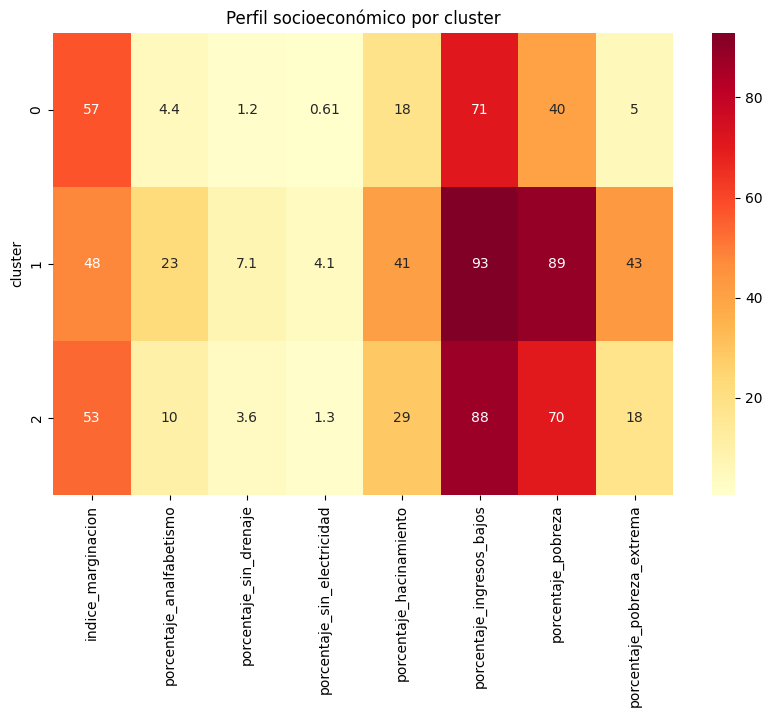

In [26]:
plt.figure(figsize=(10,6))
sns.heatmap(cluster_profile, annot=True, cmap='YlOrRd')
plt.title('Perfil socioeconómico por cluster')
plt.show()

Observamos que el gradiente de colores tiende al rojo en las features de pobreza. Es decir, K-Means está separando principalmente por **intensidad de pobreza**.

Evaluemos ahora, la relación entre los diferentes clusters y la cantidad de delitos. 

In [27]:
df.groupby('cluster')['total_delitos'].mean()

cluster
0    1915.412054
1      32.635801
2     146.236413
Name: total_delitos, dtype: float64

Tenemos: 

* Cluster 0 (marginación moderada) &rarr; 1915
* Cluster 2 (pobreza alta) &rarr; 146
* Cluster 1 (marginación extrema) &rarr; 32

Este resultado indica que una interpretación del tipo "Más pobreza &rarr; menos delitos". Algo que no podemos afirmar. 

Estos resultados pueden deberse a un factor que no hemos considerado para el clustering: el tamaño poblacional. Es evidente, que conforme más poblada es una región, ,mayor es la actividad económica y social, y por lo tanto mayores posiblidades de delincuencia.

Tenemos: 

* Municipios grandes &rarr; más delitos
* Municipios pequños &rarr; menos delitos

En realidad, se mide el tamaño del municipio, no la criminalidad real.

Consideremos la distribución del total de delitos por cada cluster vía boxplot: 

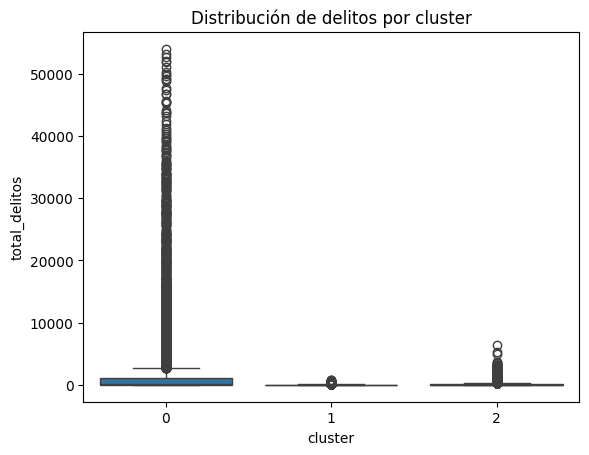

In [28]:
sns.boxplot(data=df, x='cluster', y='total_delitos')
plt.title('Distribución de delitos por cluster')
plt.show()

El boxplot muestra que el cluster `'0'` posee una gran cantidad de outliers. Este cluster se caracteriza por mejores indicadores de infraestructura, marginación moderada y alta actividad delictiva. Los municipios que integran este grupo, probablemente lo componen municipios con gran actividad social y económica, lo que provee de más oportunidaddes para que ocurra el delito. 

Los resultados del clustering sugieren la existencia de un gradiente de marginación: `Cluster 0` &rarr; `Cluster 2` &rarr; `Cluster 1`. Sin embargo, al analizar la incidencia delictiva, se observa que los municipios con menor marginación presentan mayores cantidades de delitos registrados. 

Este resultado no implica una relación inversa marginación-pobreza, sino que podría reflejar el efecto de variables no incluidas en el modelo, como el tamaño poblacional o indicadores de actividad económica. 

En particular, los municipios con marginación extrema tienden a ser más rurales, menos densos y con menor capacidad de reporte, lo que se traduce en menores niveles de delitos observados. 

A continuación, realizamos un nuevo clustering en el cual consideraremos una nueva variable: 

`tasa_delitos = total_delitos / poblacion * 100000`

Esta variable incluye la dimension poblacional en el modelo. 

## Clustering: Tasa de delitos

Definimos la variable que mide la cantidad de delitos cada 100000 habitantes: 

In [29]:
df['tasa_delitos'] = df['total_delitos'] / df['poblacion_total'] * 100000

In [30]:
df['tasa_delitos'].describe()

count    26017.000000
mean       724.257577
std        698.077742
min          0.000000
25%        227.079194
50%        511.695906
75%       1002.892960
max       7049.299851
Name: tasa_delitos, dtype: float64

Considerearemos evitar el ruido extremo inducido por los municipios pequeños (menos de 5000 habitantes). 

In [31]:
df_td = df.query("poblacion_total > 5000")

Procedemos con el clustering: 

In [32]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_td[features_clustering])

kmeans = KMeans(n_clusters=3, random_state=42)
df_td['cluster'] = kmeans.fit_predict(X_scaled)

/tmp/ipykernel_1173/1800887043.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_td['cluster'] = kmeans.fit_predict(X_scaled)


El perfil de cada cluster: 

In [33]:
cluster_profile_td = df_td.groupby('cluster')[features_clustering].mean()

Analicemos los clusters indivualmente: 

Cluster `'0'`: 

In [35]:
cluster_profile_td.iloc[0,:]

indice_marginacion             46.641247
porcentaje_analfabetismo       23.469404
porcentaje_sin_drenaje          9.627524
porcentaje_sin_electricidad     5.196471
porcentaje_hacinamiento        44.459662
porcentaje_ingresos_bajos      92.435083
porcentaje_pobreza             88.856605
porcentaje_pobreza_extrema     45.300717
Name: 0, dtype: float64

* Altísimo analfabetismo, pobreza, carencias
* Estructuralmente rezagado

Este cluster se caracteriza por marginación extrema y baja tasa de criminalidad. 

Cluster `'1'`: 

In [36]:
cluster_profile_td.iloc[1, :]

indice_marginacion             57.518886
porcentaje_analfabetismo        4.379790
porcentaje_sin_drenaje          1.174097
porcentaje_sin_electricidad     0.558494
porcentaje_hacinamiento        18.610994
porcentaje_ingresos_bajos      70.425875
porcentaje_pobreza             41.517024
porcentaje_pobreza_extrema      5.243504
Name: 1, dtype: float64

* Mejores condiciones relativo a los demás clusters

La marginación es moderada. 

Cluster `'2'`: 

In [37]:
cluster_profile_td.iloc[2,:]

indice_marginacion             53.334500
porcentaje_analfabetismo       10.729107
porcentaje_sin_drenaje          3.828191
porcentaje_sin_electricidad     1.360598
porcentaje_hacinamiento        29.784070
porcentaje_ingresos_bajos      86.374530
porcentaje_pobreza             69.509970
porcentaje_pobreza_extrema     17.904973
Name: 2, dtype: float64

* Alto pero no extremo
* Condiciones socioeconómicas estables

El cluster posee condiciones de pobreza alta. 

En cuanto a los cambios realizados, los clusters no cambian demasiado. Los perfiles siguen siendo prácticamente los mismos, solo cambió el orden.

Consideremos ahora el análisis de la tasa de delitos. 

In [38]:
df_td.groupby('cluster')['tasa_delitos'].agg(['mean', 'median', 'std'])

,mean,median,std
cluster,,,
0,203.352993,148.544266,182.351922
1,1229.353979,1074.595182,827.507292
2,558.212294,463.233182,425.588798


Ahora el patrón parece más consistente: **Menor marginación &rarr; mayor tasa de delitos**.

**Cluster 0 - Marginación extrema &rarr; baja tasa**

Esto no implica menos crimen necesariamente. Las posibles explicaciones: 

* Baja densidad poblacional
* Menor actividad
* Falta de registros
* Tipos de delitos distintos (menos denunciados)

**Cluster 1 - Menor marginación &rarr; tasa alta**

El delito parace estar asociado a entornos más desarrollados y con alta actividad. Los posibles factores: 

* Mayor densidad
* Mas oportunidades delictivas
* Mejor capacidad de denunciar y registrar. 

La incidencia delictiva (medida como tasa) muestra una relación inversa con la marginación socioeconómica.  Este resltado no debe interpretarse como que la pobreza reduce el crimen, sino como evidencia de que el delito registrado es influenciado por otros factores como la urbanización, la actividad económica y la capacidad institucional para el registro de delitos.

## Conclusiones

### Clustering

El clustering mediante K-Means permitió identificar **tres tipos de munucipios** en México en base a sus características socieconómicas. Estos grupos siguen un **gradiente de marginación**, que va desde municipios con condiciones relativamente favorables hasta aquellos con rezago estructural. 

Se probaron dos configuraciones para el clustering y los grupos obtenidos no cambiaron significativamente. Esto muestra que los clusters son consistentes y estables, lo que sugiere que las variables utilizadas capturan la estructura socioeconómica subyaciente. En particular, los clusters encontrados: 

* Un grupo de municipios con **baja marginación relativa**, caracterizado por bajos niveles de pobreza, analfabetismo y carencias en servicios.
* Un grupo intermedio con **altos niveles de pobreza**, pero sin alcanzar condiciones extremas.
* Un grupo con **marginación alta**, donde se concentran múltiples carencias simultáneamente.


Este resultado sugiere que la desigualdad socioeconómica a nivel municipal no es aleatoria, sino que presenta **patrones bien definidos** que pueden ser capturados mediante técnicas de clustering.

### Relación con incidencia delictiva

Al analizar la incidencia delictiva utilizando tasas (en lugar de totales), se observa un patron consistente.

> menor marginación &rarr; mayor tasa de delitos

Este resultado **no implica relación causal inversa entre marginación y criminalidad**. Más bien, sugiere que la incidencia delictiva es influida por factores no incluidos en el modelo, como: 

* urbanización
* densidad poblacional
* actividad económica
* capacidad institucional de registro delictivo

### Limitaciones

Este análisis debe interpretarse como **exploratorio**, dadas las siguientes limitaciones. 

1. Colinealidad en las variables
   Las variables socioeconómicas utilizadas están **altamente correlacionadas** (pobreza, analfabetismo, carencias), lo que implica que los clusters reflegan principalmente esta única dimensión.
   
2. Variables omitidas relevantes
   No se incluyeron variables que podrían ser clave para explicar el delito, como:

   * grado de urbanización
   * actividad económica
   * capacidad institucional
   Esto limita la interpretación enter clusters y criminalidad.

3. Posible subregistro
   En municipios con alta marginación, la incidencia delictiva puede estar subestimada debido a menor acceso a limitaciones. 


### Posibles mejoras

A partir de este análisis, se identificaron varias líneas claras de mejora: 

1. Incorporación de variables menos correlacionadas
   Especialmente, variables como densidad poblacional, proporcion de población urbama, tamaño del municipio e indicadores económicos. Estas variables añaden explicabilidad y permiten medir la dinámica social y económica de los municipios.

2. Uso de la tasa de delitos (ya implementado)
   Este ajuste de importante para evitar sesgos por tamaño poblacional y permitió una interpretación más adecuada.
   
3. Incorporación de dimensión espacial
   Las variables geográficas aportarían contexto e interpretabildiad al modelo.

El análisis de clustering permitió identificar patrones claros en la estructura socioeconómica de los municipios mexicanos y evidenció que la incidencia delictiva no puede explicarse únicamente por niveles de marginación. Los resultados sugieren que otros factores como la urbanización y la capacidad institucional juegan un papel importante.